In [ ]:
import hashlib
import json
import math
import time
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Iterable, List, Optional, Tuple

import numpy as np
import pandas as pd
import requests
from tqdm.auto import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 160)

print("numpy", np.__version__)
print("pandas", pd.__version__)

numpy 2.0.2
pandas 2.2.2


In [ ]:
from pathlib import Path

_path = Path("raw_dataset.parquet")
if not _path.exists():
    _path = Path("raw_dataset(2).parquet")
prices = pd.read_parquet(_path)
prices

,SBER,SBERP,GAZP,LKOH,ROSN,NVTK,TATN,TATNP,GMKN,CHMF,NLMK,MAGN,ALRS,PLZL,PHOR,MGNT,MTSS,RTKM,SNGS,SNGSP,AFKS,MOEX,VTBR,YDEX,AFLT,FEES,IRAO,HYDR,TRNFP,BSPB,PIKK,FIVE,UPRO,CBOM,VKCO,T,OZON,POSI,RUAL,ENPG,SPBE,ASTR,FESH,NMTP,BELU,HEAD,LSRG,MSNG,TGKN,UNAC,CNTL,RNFT,FLOT,SMLT,SOFL,DELI,SBMX,SBRB,LQDT,TITR,EQMX,AKMB,SBCB,SBGB,FXUS,FXCN,FXIT,FXMM,SBHI,TBRU,TMOS,TECH,SU26238RMFS4,SU26243RMFS4,SU26244RMFS2,SU26233RMFS5,SU26234RMFS3,USD000UTSTOM,EUR_RUB__TOM,CHFRUB_TOM,JPYRUB_TOM,KZTRUB_TOM,BYNRUB_TOM,GLDRUB_TOM,SLVRUB_TOM,PLDRUB_TOM
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,NaN,1.000000,NaN,NaN,NaN,NaN,1.000000,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-05,1.008979,1.004737,1.011415,1.030214,1.008765,1.004553,1.022635,0.997506,1.018269,1.025778,0.988126,1.006908,1.046912,1.008741,0.993298,0.998592,1.011034,0.983277,1.003965,1.004807,1.026644,1.026674,0.975774,NaN,0.968861,1.023794,1.112647,1.037087,1.014599,0.993143,0.989327,NaN,NaN,0.983461,NaN,NaN,NaN,NaN,1.027123,NaN,NaN,NaN,1.011111,0.978408,NaN,NaN,1.027937,1.040804,1.021930,1.039926,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.015779,1.000000,1.011450,1.000167,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.002132,0.993338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-06,0.988164,0.982945,1.007635,1.029348,1.005578,0.994746,1.029148,0.990025,1.007622,1.070974,0.988126,1.023911,1.044919,1.010490,0.996825,0.995953,1.007436,0.999887,0.998678,0.997940,1.025794,1.028198,0.973831,NaN,0.961744,1.017929,1.154941,1.024977,1.037539,0.997714,0.986079,NaN,NaN,0.988550,NaN,NaN,NaN,NaN,1.022232,NaN,NaN,NaN,1.018519,0.997301,NaN,NaN,1.048711,1.034105,1.021930,0.984215,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.026824,1.007371,1.015614,1.000668,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.021870,1.017287,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-01-11,0.928783,0.935436,0.973834,0.977361,0.960359,0.964098,0.987136,0.976559,0.963909,1.035989,0.996910,0.992827,1.016301,1.059441,0.991182,0.954317,0.962101,0.977627,0.975037,0.993362,0.996315,1.028851,0.936002,NaN,0.926335,0.984249,1.109394,1.000606,1.046924,0.982857,0.969374,NaN,NaN,0.986005,NaN,NaN,NaN,NaN,0.991552,NaN,NaN,NaN,1.003704,0.990553,NaN,NaN,0.996418,1.003654,0.973684,0.942433,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.003156,0.963145,0.988203,1.000835,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.041703,1.044543,NaN,NaN,NaN,NaN,inf,inf,NaN
2016-01-12,0.935721,0.938278,0.989845,0.962471,0.955777,0.992995,0.995603,0.962594,0.958642,1.037831,1.023285,0.971573,1.056693,1.111888,0.997531,0.927478,0.983449,0.966102,1.001468,1.007553,0.995465,1.020686,0.953750,NaN,0.947509,0.987768,1.101261,1.025583,1.056830,0.995429,0.974942,NaN,NaN,0.972010,NaN,NaN,NaN,NaN,0.995998,NaN,NaN,NaN,1.007407,0.975709,NaN,NaN,0.975645,1.007917,0.991228,0.899721,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.016963,0.975430,1.010409,1.001085,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.053376,1.055521,NaN,NaN,NaN,NaN,inf,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,5.621107,7.589444,2.216676,5.750005,3.266478,2.952950,4.672223,7.208750,3.032147,3.407579,3.470186,2.685190,1.031169,12.214659,6.859639

In [ ]:
prices.isna().mean().sort_values(ascending=False)

,0
TECH,0.954076
T,0.863758
PLDRUB_TOM,0.851894
HEAD,0.845006
YDEX,0.827401
...,...
AFLT,0.006889
PIKK,0.006889
HYDR,0.006889
USD000UTSTOM,0.000000


In [ ]:
sum(prices.isna().mean().values > 0.15)

np.int64(40)

In [ ]:
from pathlib import Path

_path = Path("raw_absolute_prices.parquet")
if not _path.exists():
    _path = Path("raw_absolute_prices(2).parquet")
prices_close = pd.read_parquet(_path)
prices_close

,SBER,SBERP,GAZP,LKOH,ROSN,NVTK,TATN,TATNP,GMKN,CHMF,NLMK,MAGN,ALRS,PLZL,PHOR,MGNT,MTSS,RTKM,SNGS,SNGSP,AFKS,MOEX,VTBR,YDEX,AFLT,FEES,IRAO,HYDR,TRNFP,BSPB,PIKK,FIVE,UPRO,CBOM,VKCO,T,OZON,POSI,RUAL,ENPG,SPBE,ASTR,FESH,NMTP,BELU,HEAD,LSRG,MSNG,TGKN,UNAC,CNTL,RNFT,FLOT,SMLT,SOFL,DELI,SBMX,SBRB,LQDT,TITR,EQMX,AKMB,SBCB,SBGB,FXUS,FXCN,FXIT,FXMM,SBHI,TBRU,TMOS,TECH,SU26238RMFS4,SU26243RMFS4,SU26244RMFS2,SU26233RMFS5,SU26234RMFS3,USD000UTSTOM,EUR_RUB__TOM,CHFRUB_TOM,JPYRUB_TOM,KZTRUB_TOM,BYNRUB_TOM,GLDRUB_TOM,SLVRUB_TOM,PLDRUB_TOM
TRADEDATE,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
2016-01-04,98.01,73.88,134.91,2310.2,251.00,571.0,307.05,200.5,8922.00,597.4,61.48,18.820,55.21,2860.0,2835.0,11366.0,208.45,88.50,34.050,43.690,17.640,91.85,0.07719,NaN,56.20,0.05968,1.2295,0.6606,191800.0,43.75,215.5,NaN,NaN,3.930,NaN,NaN,NaN,NaN,22.490,NaN,NaN,NaN,2.70,3.705,NaN,NaN,698.0,0.8210,0.001140,0.5385,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2535.0,2035.0,2882.0,1198.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.1600,79.250,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-05,98.89,74.23,136.45,2380.0,253.20,573.6,314.00,200.0,9085.00,612.8,60.75,18.950,57.80,2885.0,2816.0,11350.0,210.75,87.02,34.185,43.900,18.110,94.30,0.07532,NaN,54.45,0.06110,1.3680,0.6851,194600.0,43.45,213.2,NaN,NaN,3.865,NaN,NaN,NaN,NaN,23.100,NaN,NaN,NaN,2.73,3.625,NaN,NaN,717.5,0.8545,0.001165,0.5600,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2575.0,2035.0,2915.0,1198.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,73.3160,78.722,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-06,96.85,72.62,135.94,2378.0,252.40,568.0,316.00,198.5,8990.00,639.8,60.75,19.270,57.69,2890.0,2826.0,11320.0,210.00,88.49,34.005,43.600,18.095,94.44,0.07517,NaN,54.05,0.06075,1.4200,0.6771,199000.0,43.65,212.5,NaN,NaN,3.885,NaN,NaN,NaN,NaN,22.990,NaN,NaN,NaN,2.75,3.695,NaN,NaN,732.0,0.8490,0.001165,0.5300,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2603.0,2050.0,2927.0,1199.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,74.7600,80.620,NaN,NaN,NaN,NaN,0.0,0.00,NaN
2016-01-11,91.03,69.11,131.38,2257.9,241.05,550.5,303.10,195.8,8600.00,618.9,59.34,18.685,56.11,3030.0,2810.0,10667.0,200.55,86.52,33.200,43.400,17.575,94.50,0.07225,NaN,52.06,0.05874,1.3640,0.6610,200800.0,43.00,208.9,NaN,NaN,3.875,NaN,NaN,NaN,NaN,22.300,NaN,NaN,NaN,2.71,3.670,NaN,NaN,695.5,0.8240,0.001110,0.5075,21.35,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2543.0,1960.0,2848.0,1199.2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,76.2110,82.780,NaN,NaN,NaN,NaN,2690.1,34.20,NaN
2016-01-12,91.71,69.32,133.54,2223.5,239.90,567.0,305.70,193.0,8553.00,620.0,60.91,18.285,58.34,3180.0,2828.0,10367.0,205.00,85.50,34.100,44.020,17.560,93.75,0.07362,NaN,53.25,0.05895,1.3540,0.6775,202700.0,43.55,210.1,NaN,NaN,3.820,NaN,NaN,NaN,NaN,22.400,NaN,NaN,NaN,2.72,3.615,NaN,NaN,681.0,0.8275,0.001130,0.4845,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2578.0,1985.0,2912.0,1199.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,77.0650,83.650,NaN,NaN,NaN,NaN,2653.0,0.00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-24,325.19,325.10,123.25,5476.5,437.45,1184.0,594.90,557.7,137.76,800.2,90.92,26.170,29.96,2289.8,7019.0,2768.5,223.20,56.04,20.325,43.420,11.941,173.39,94.24000,4284.5,48.99,0.07012,3.2405,0.4183,1384.8,338.30,534.5,NaN,1.4060,6.489,262.10,320.16,4348.0,1075.2,41.250,446.05,218.4,267.5,78.82,8.400,389.8,2972.0,657.8,1.9650,0.005840,0.3960,9.10,114.10,82.41,635.8,70.90,83.30,18.578,18.689,1.9765,5.32,142.20,1.9742,1335.0,15.688,NaN,NaN,NaN,NaN,7.342,8.24,6.47,NaN,59.030,75.325,86.602,60.112,NaN,74.6900,0.000,0.0,0.0,16.5600,26.5700,11345.0,185.00,3555.50
2026-04-27,321.99,322.11,123.29,5553.0,439.95,117

In [ ]:
from pathlib import Path

_path = Path("assets_df.parquet")
if not _path.exists():
    _path = Path("assets_df(2).parquet")
assets_df = pd.read_parquet(_path)
assets_df

,engine,market,board,asset_type
secid,,,,
AFKS,stock,shares,TQBR,equity
AFLT,stock,shares,TQBR,equity
AKMB,stock,shares,TQTF,fund
ALRS,stock,shares,TQBR,equity
ASTR,stock,shares,TQBR,equity
...,...,...,...,...
UPRO,stock,shares,TQBR,equity
USD000UTSTOM,currency,selt,CETS,fx
VKCO,stock,shares,TQBR,equity


In [ ]:
MOEX_BASE = "https://iss.moex.com/iss"
MOEX_HTTP_TIMEOUT: Tuple[float, float] = (10.0, 60.0)

def _get_json(
    url: str,
    params: Optional[dict] = None,
    timeout: Optional[Tuple[float, float]] = None,
    max_retries: int = 3,
) -> dict:
    tout = timeout if timeout is not None else MOEX_HTTP_TIMEOUT
    for attempt in range(max_retries):
        try:
            r = requests.get(url, params=params or {}, timeout=tout)
            r.raise_for_status()
            return r.json()
        except (requests.exceptions.Timeout, requests.exceptions.ConnectionError):
            if attempt >= max_retries - 1:
                raise
            time.sleep(0.5 * (attempt + 1))

def moex_security_info(secid: str, engine: str = "stock", market: str = "shares") -> dict:
    """Возвращает базовую инфу о бумаге, включая LOTSIZE (если доступно)."""
    url = f"{MOEX_BASE}/engines/{engine}/markets/{market}/securities/{secid}.json"
    js = _get_json(url, params={"iss.meta": "off"})

    sec_cols = js["securities"]["columns"]
    sec_data = js["securities"]["data"]
    sec = (pd.DataFrame(sec_data, columns=sec_cols).iloc[0].to_dict()) if len(sec_data) else {}

    mdata_cols = js.get("marketdata", {}).get("columns", [])
    mdata_data = js.get("marketdata", {}).get("data", [])
    mdata = (pd.DataFrame(mdata_data, columns=mdata_cols).iloc[0].to_dict()) if len(mdata_data) else {}

    return {**sec, **{f"MD_{k}": v for k, v in mdata.items()}}


def load_lot_sizes_assets(assets: List[dict]) -> pd.Series:
    lot = {}
    for a in tqdm(list(assets), desc="MOEX security info (multi-asset)"):
        secid = a["secid"]
        info = moex_security_info(
            secid,
            engine=a.get("engine", "stock"),
            market=a.get("market", "shares"),
        )
        lotsize = info.get("LOTSIZE")
        lot[secid] = int(lotsize) if lotsize not in (None, "", np.nan) else 1
        time.sleep(0.05)
    return pd.Series(lot, name="LOTSIZE").astype(int)

Исключены активы (последнее значение 0 или есть inf): ['CHFRUB_TOM', 'EUR_RUB__TOM', 'GLDRUB_TOM', 'SLVRUB_TOM']


,engine,market,board,asset_type
SBER,stock,shares,TQBR,equity
SBERP,stock,shares,TQBR,equity
GAZP,stock,shares,TQBR,equity
LKOH,stock,shares,TQBR,equity
ROSN,stock,shares,TQBR,equity
NVTK,stock,shares,TQBR,equity
TATN,stock,shares,TQBR,equity
TATNP,stock,shares,TQBR,equity
GMKN,stock,shares,TQBR,equity
CHMF,stock,shares,TQBR,equity


,0
SBER,1
SBERP,1
GAZP,1
LKOH,1
ROSN,1
NVTK,1
TATN,1
TATNP,1
GMKN,1
CHMF,1


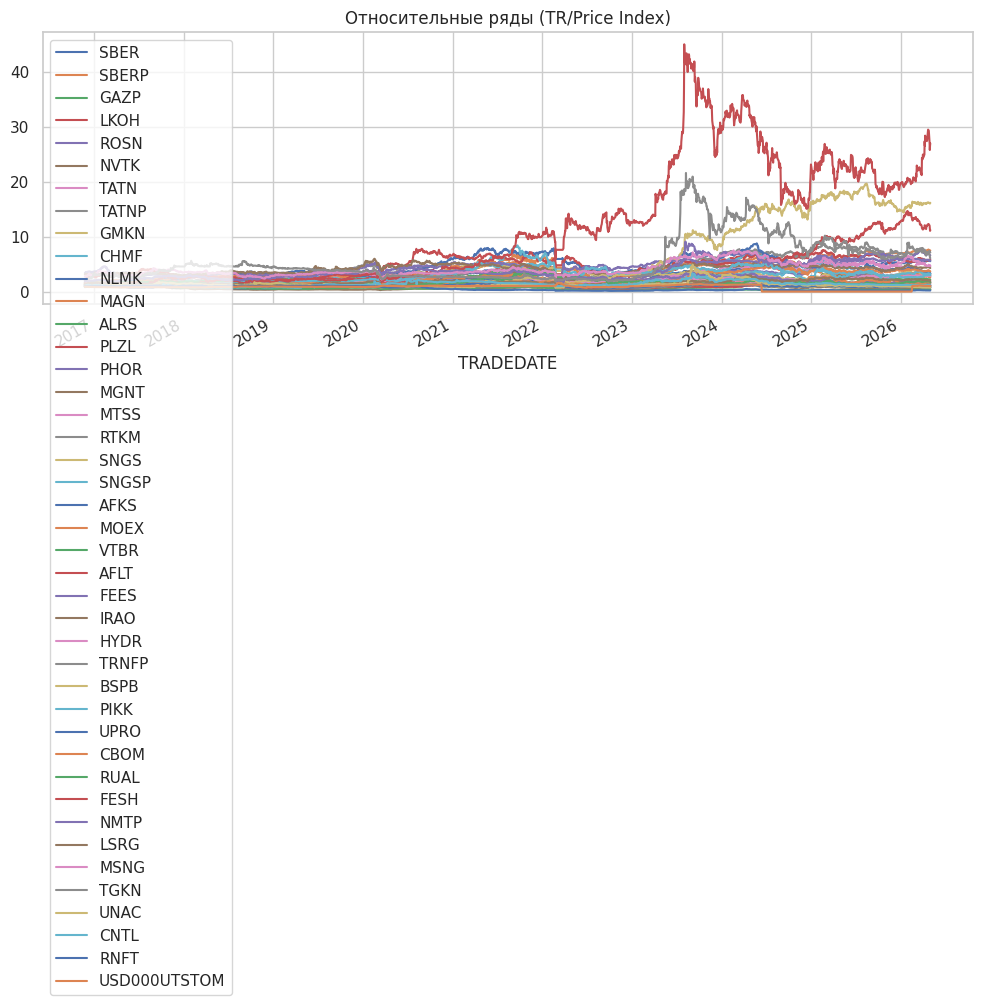

In [ ]:
SECIDS = [
    "SBER",
    "SBERP",
    "GAZP",
    "LKOH",
    "ROSN",
    "NVTK",
    "TATN",
    "TATNP",
    "GMKN",
    "CHMF",
    "NLMK",
    "MAGN",
    "ALRS",
    "PLZL",
    "PHOR",
    "MGNT",
    "MTSS",
    "RTKM",
    "SNGS",
    "SNGSP",
    "AFKS",
    "MOEX",
    "VTBR",
    "YDEX",
    "AFLT",
    "FEES",
    "IRAO",
    "HYDR",
    "TRNFP",
    "BSPB",
    "PIKK",
    "FIVE",
    "UPRO",
    "CBOM",
    "VKCO",
    "T",
    "OZON",
    "POSI",
    "RUAL",
    "ENPG",
    "SPBE",
    "ASTR",
    "FESH",
    "NMTP",
    "BELU",
    "HEAD",
    "LSRG",
    "MSNG",
    "TGKN",
    "UNAC",
    "CNTL",
    "RNFT",
    "FLOT",
    "SMLT",
    "SOFL",
    "DELI",
]


# Универсум активов (можно менять/расширять)
# asset_type: equity | fund | bond | fx | metal
ASSETS: List[dict] = []

# Акции (TQBR)
ASSETS += [
    {"secid": s, "engine": "stock", "market": "shares", "board": "TQBR", "asset_type": "equity"}
    for s in SECIDS
]

# Чтобы расчёты были стабильнее, отфильтруем активы с большим числом пропусков
max_nan_share = 0.15

# фильтрация на относительных рядах (prices)
keep = prices.columns[prices.isna().mean() <= max_nan_share]
prices = prices[keep].dropna(how="all").ffill().dropna()

# убираем активы с нулём в последней точке или с inf в ряду
_last = prices.iloc[-1]
_has_inf = pd.Series(np.isinf(prices.to_numpy(dtype=float)).any(axis=0), index=prices.columns)
_ok = (_last != 0) & (~_has_inf)
removed = sorted(prices.columns[~_ok].tolist())
if removed:
    print("Исключены активы (последнее значение 0 или есть inf):", removed)
prices = prices.loc[:, _ok]

# синхронизируем absolute цены и метаданные
prices_close = prices_close[prices.columns].ffill().dropna()
assets_df = assets_df.loc[prices.columns]

# Для автономного запуска без интернета используем 1 лот = 1 акция.
lot_size = pd.Series(1, index=prices.columns, dtype=int)

display(assets_df)
display(lot_size)

prices.plot(figsize=(12, 4), title="Относительные ряды (TR/Price Index)")
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def portfolio_metrics_rolling(
    weights: dict[str, float] | pd.Series,
    prices: pd.DataFrame,
    window: int = 252,
    trading_days: int = 252,
    normalize: bool = True,
    allow_short: bool = False,
    plot: bool = True,
) -> dict:
    """
    Считает доходность и rolling-риск портфеля.

    weights: {"SBER": 0.4, "GAZP": 0.6}
    prices: DataFrame цен по тикерам
    window: размер rolling-окна, обычно 252 торговых дня
    """

    w = pd.Series(weights, dtype=float)

    if not allow_short and (w < 0).any():
        bad = w[w < 0]
        raise ValueError(f"Negative weights are not allowed: {bad.to_dict()}")

    missing = [t for t in w.index if t not in prices.columns]
    if missing:
        raise KeyError(f"Tickers not found in prices: {missing}")

    if normalize:
        s = float(w.sum())
        if s == 0:
            raise ValueError("Sum of weights is 0.")
        w = w / s

    tickers = list(w.index)
    prices_sub = prices[tickers]

    logret = np.log(prices_sub / prices_sub.shift(1)).dropna()

    # доходность портфеля во времени
    portfolio_ret_daily = logret @ w

    mu_daily = portfolio_ret_daily.mean()
    mu_ann = float(mu_daily * trading_days)

    # rolling covariance matrices
    rolling_cov = logret.rolling(window).cov()

    rolling_var = []

    for date in logret.index[window - 1:]:
        cov_t = rolling_cov.loc[date].loc[tickers, tickers]
        var_t = float(w.values @ cov_t.values @ w.values)
        rolling_var.append((date, var_t * trading_days))

    rolling_var = pd.Series(
        data=[x[1] for x in rolling_var],
        index=[x[0] for x in rolling_var],
        name="rolling_var_ann"
    )

    rolling_sigma = np.sqrt(rolling_var.clip(lower=0))
    rolling_sigma.name = "rolling_sigma_ann"

    sigma_q_0_8 = rolling_sigma.quantile(0.8)
    sigma_q_0_9 = rolling_sigma.quantile(0.9)
    sigma_q_0_95 = rolling_sigma.quantile(0.95)

    result = {
        "weights": w,
        "mu_ann": mu_ann,
        "rolling_var_ann": rolling_var,
        "rolling_sigma_ann": rolling_sigma,
        "mean_var_ann": float(rolling_var.mean()),
        "median_var_ann": float(rolling_var.median()),
        "mean_sigma_ann": float(rolling_sigma.mean()),
        "median_sigma_ann": float(rolling_sigma.median()),
        "sigma_q_0.8": sigma_q_0_8,
        "sigma_q_0.9": sigma_q_0_9,
        "sigma_q_0.95": sigma_q_0_95,

    }

    if plot:
        plt.figure(figsize=(10, 5))
        plt.plot(rolling_var.index, rolling_var.values, label="Rolling portfolio variance")
        plt.title(f"Rolling Portfolio Variance, window={window}")
        plt.xlabel("Date")
        plt.ylabel("Annualized variance")
        plt.legend()
        plt.grid(True)
        plt.show()

        plt.figure(figsize=(10, 5))
        plt.plot(rolling_sigma.index, rolling_sigma.values, label="Rolling portfolio sigma")
        plt.title(f"Rolling Portfolio Risk / Volatility, window={window}")
        plt.xlabel("Date")
        plt.ylabel("Annualized sigma")
        plt.legend()
        plt.grid(True)
        plt.show()

    return result

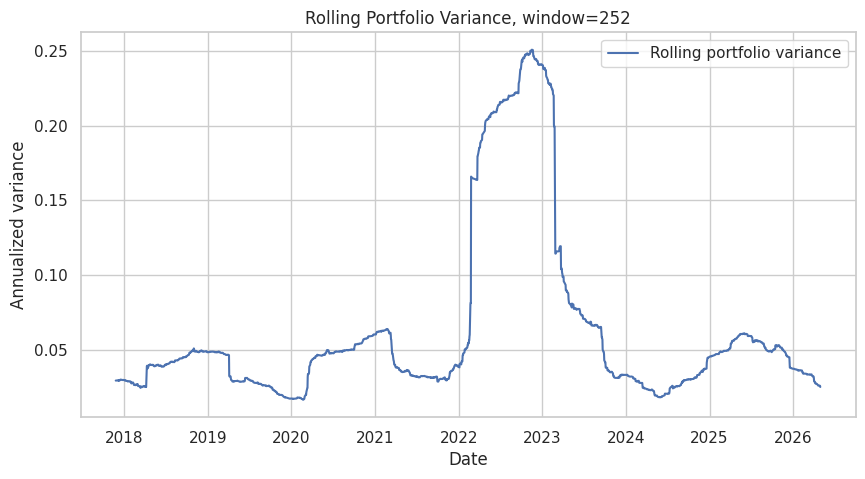

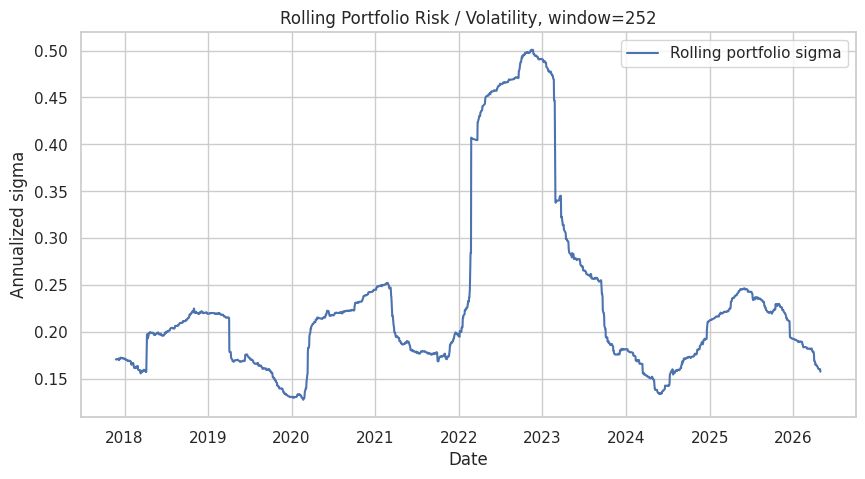

{'weights': SBER    0.5
 LKOH    0.1
 PHOR    0.4
 dtype: float64,
 'mu_ann': 0.15952017091210124,
 'rolling_var_ann': 2017-11-24    0.029284
 2017-11-27    0.029345
 2017-11-28    0.029295
 2017-11-29    0.029349
 2017-11-30    0.029440
                 ...   
 2026-04-24    0.025831
 2026-04-27    0.025921
 2026-04-28    0.025723
 2026-04-29    0.025712
 2026-04-30    0.024990
 Name: rolling_var_ann, Length: 2135, dtype: float64,
 'rolling_sigma_ann': 2017-11-24    0.171127
 2017-11-27    0.171305
 2017-11-28    0.171159
 2017-11-29    0.171315
 2017-11-30    0.171582
                 ...   
 2026-04-24    0.160719
 2026-04-27    0.160999
 2026-04-28    0.160384
 2026-04-29    0.160349
 2026-04-30    0.158082
 Name: rolling_sigma_ann, Length: 2135, dtype: float64,
 'mean_var_ann': 0.0627264710802458,
 'median_var_ann': 0.044048260807066676,
 'mean_sigma_ann': 0.2321454797122583,
 'median_sigma_ann': 0.2098767752922335,
 'sigma_q_0.8': np.float64(0.2489792754044934),
 'sigma_q_0.9': n

In [ ]:
portfolio_metrics_rolling(
    {"SBER": 0.5,  "LKOH": 0.1, "PHOR": 0.4},
    prices
)

## Быстрая оптимизация портфеля методом Grey Wolf Optimizer (GWO)

В этой версии оставлен метод из списка на скриншоте — **Grey Wolf Optimizer**.

Чтобы ноутбук не зависал в Colab, расчёт упрощён:

1. Берётся ограниченный универсум активов `ASSET_LIMIT`.
2. Внутри оптимизатора риск считается быстро через ковариационную матрицу, а не через тяжёлый rolling-расчёт на каждой итерации.
3. Количество волков и итераций уменьшено.
4. Целые лоты считаются напрямую через бюджет, без долгих циклов докупки по одному лоту.
5. В конце лучший портфель дополнительно проверяется через исходную функцию `portfolio_metrics_rolling`.

То есть GWO быстро ищет кандидатный портфель, а финальная проверка остаётся через твою исходную целевую функцию.


In [ ]:
import random
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

In [ ]:
from typing import List, Tuple, Dict


OPT_TRADING_DAYS = 252
ASSET_LIMIT = 25

_px_all = prices.astype(np.float64).replace([0, np.inf, -np.inf], np.nan).ffill().bfill()
_ret_all = np.log(_px_all / _px_all.shift(1)).replace([np.inf, -np.inf], np.nan)

valid_cols = []
for col in _ret_all.columns:
    ok_hist = _ret_all[col].notna().mean() > 0.85
    ok_price = col in prices_close.columns and pd.notna(prices_close[col].ffill().iloc[-1])
    if ok_hist and ok_price:
        valid_cols.append(col)

_ret_valid = _ret_all[valid_cols].dropna(how="any")

_mu_tmp = _ret_valid.mean() * OPT_TRADING_DAYS
_sig_tmp = _ret_valid.std() * np.sqrt(OPT_TRADING_DAYS)
_score_tmp = (_mu_tmp / _sig_tmp.replace(0, np.nan)).replace([np.inf, -np.inf], np.nan).fillna(-999)

OPT_TICKERS: List[str] = list(_score_tmp.sort_values(ascending=False).head(ASSET_LIMIT).index)
OPT_N = len(OPT_TICKERS)

logret_df = _ret_valid[OPT_TICKERS].dropna(how="any")
MU_VEC = logret_df.mean().values.astype(np.float64) * OPT_TRADING_DAYS
COV_MAT = logret_df.cov().values.astype(np.float64) * OPT_TRADING_DAYS
COV_MAT = np.nan_to_num(COV_MAT, nan=0.0, posinf=0.0, neginf=0.0)

print(f"Активов в быстрой оптимизации: {OPT_N}")
print(OPT_TICKERS)


def metrics_from_weights_fast(w: np.ndarray) -> Tuple[float, float]:
    """Быстрый proxy-расчёт: годовая доходность и годовой риск через covariance matrix."""
    w = np.asarray(w, dtype=np.float64)
    s = float(w.sum())
    if s <= 0:
        return -1e9, 1e9
    w = w / s
    mu_ann = float(w @ MU_VEC)
    sigma_ann = float(np.sqrt(max(w @ COV_MAT @ w, 0.0)))
    return mu_ann, sigma_ann


def weights_dict_from_vec(w: np.ndarray, thr: float = 1e-8) -> dict:
    w = np.asarray(w, dtype=np.float64)
    s = float(w.sum())
    if s <= 0:
        return {}
    w = w / s
    return {OPT_TICKERS[i]: float(wi) for i, wi in enumerate(w) if wi > thr}


def n_active_assets(w: np.ndarray, thr: float = 1e-8) -> int:
    return int((np.asarray(w) > thr).sum())


Активов в быстрой оптимизации: 25
['PHOR', 'BSPB', 'FESH', 'PLZL', 'TATNP', 'SBERP', 'SNGSP', 'LKOH', 'TATN', 'MOEX', 'SBER', 'MTSS', 'NMTP', 'GMKN', 'ROSN', 'PIKK', 'NVTK', 'TGKN', 'CHMF', 'TRNFP', 'MSNG', 'GAZP', 'NLMK', 'CBOM', 'RUAL']


In [ ]:
CARDINALITY_K = 10
BUDGET_RUB = 1_000_000
TRANSACTION_COST = 0.0005
MIN_LOTS_PER_ASSET = 1
SEED = 42

if "lot_size" in globals():
    _lots = lot_size.reindex(OPT_TICKERS).fillna(1).astype(int)
elif "LOTSIZE" in assets_df.columns:
    if set(OPT_TICKERS).issubset(set(assets_df.index)):
        _lots = assets_df["LOTSIZE"].reindex(OPT_TICKERS).fillna(1).astype(int)
    elif "secid" in assets_df.columns:
        _lots = assets_df.set_index("secid")["LOTSIZE"].reindex(OPT_TICKERS).fillna(1).astype(int)
    else:
        _lots = pd.Series(1, index=OPT_TICKERS, dtype=int)
else:
    _lots = pd.Series(1, index=OPT_TICKERS, dtype=int)

_last_prices = prices_close.reindex(columns=OPT_TICKERS).replace([0, np.inf, -np.inf], np.nan).ffill().iloc[-1].fillna(0)
LOT_SIZE = _lots.values.astype(int)
LAST_PRICE = _last_prices.values.astype(float)
LOT_VALUE = LAST_PRICE * LOT_SIZE

VALID_ASSET_MASK = np.isfinite(LOT_VALUE) & (LOT_VALUE > 0)
VALID_IDX = np.where(VALID_ASSET_MASK)[0]


def lots_to_weights(lots: np.ndarray) -> np.ndarray:
    values = np.asarray(lots, dtype=np.float64) * LOT_VALUE
    total = float(values.sum())
    if total <= 0:
        return np.zeros(OPT_N, dtype=np.float64)
    return values / total


def portfolio_cost(lots: np.ndarray) -> float:
    return float(np.dot(lots, LOT_VALUE)) * (1.0 + TRANSACTION_COST)


def repair_lots(lots: np.ndarray) -> np.ndarray:
    """Быстро чинит ограничения: валидность, cardinality, бюджет."""
    lots = np.asarray(lots, dtype=int).clip(min=0).copy()
    lots[~VALID_ASSET_MASK] = 0

    active = np.where(lots > 0)[0]
    if len(active) > CARDINALITY_K:
        values = lots[active] * LOT_VALUE[active]
        keep = active[np.argsort(-values)[:CARDINALITY_K]]
        mask = np.zeros(OPT_N, dtype=bool)
        mask[keep] = True
        lots[~mask] = 0

    cost = portfolio_cost(lots)
    if cost > BUDGET_RUB and cost > 0:
        scale = BUDGET_RUB / cost * 0.995
        lots = np.floor(lots * scale).astype(int)

    guard = 0
    while portfolio_cost(lots) > BUDGET_RUB and lots.sum() > 0 and guard < 200:
        active = np.where(lots > 0)[0]
        j = active[np.argmax(lots[active] * LOT_VALUE[active])]
        lots[j] -= 1
        guard += 1

    return lots


def position_to_lots(position: np.ndarray) -> np.ndarray:
    """Перевод непрерывной позиции волка в реальные целые лоты."""
    x = np.asarray(position, dtype=np.float64).copy()
    x = np.nan_to_num(x, nan=0.0, posinf=1.0, neginf=0.0)
    x = np.clip(x, 0.0, 1.0)
    x[~VALID_ASSET_MASK] = 0.0

    if float(x.sum()) <= 0:
        return np.zeros(OPT_N, dtype=int)

    active = np.argsort(-x)[:CARDINALITY_K]
    active = active[(x[active] > 0) & VALID_ASSET_MASK[active]]
    if len(active) == 0:
        return np.zeros(OPT_N, dtype=int)

    weights = x[active] / x[active].sum()
    budget_without_fee = BUDGET_RUB / (1.0 + TRANSACTION_COST)

    lots = np.zeros(OPT_N, dtype=int)
    for idx, weight in zip(active, weights):
        target_money = budget_without_fee * float(weight)
        lots[idx] = int(np.floor(target_money / LOT_VALUE[idx]))

    for idx in active:
        if lots[idx] <= 0 and LOT_VALUE[idx] * (1.0 + TRANSACTION_COST) <= BUDGET_RUB:
            lots[idx] = MIN_LOTS_PER_ASSET

    return repair_lots(lots)


def objective_lots(lots: np.ndarray, sigma_max: float, penalty_lambda: float = 10.0) -> Tuple[float, float, float, bool]:
    w = lots_to_weights(lots)
    mu_ann, sig_ann = metrics_from_weights_fast(w)
    violation = max(0.0, sig_ann - sigma_max)
    score = mu_ann - penalty_lambda * violation
    feasible = (
        sig_ann <= sigma_max + 1e-12
        and portfolio_cost(lots) <= BUDGET_RUB + 1e-9
        and n_active_assets(w) <= CARDINALITY_K
        and lots.sum() > 0
    )
    return float(score), float(mu_ann), float(sig_ann), bool(feasible)


In [ ]:
def grey_wolf_optimizer_fast(
    sigma_max: float,
    n_iter: int = 35,
    n_wolves: int = 14,
    seed: int = SEED,
) -> Tuple[np.ndarray, List[float]]:
    rng = np.random.default_rng(seed)

    wolves = rng.random((n_wolves, OPT_N))
    wolves[:, ~VALID_ASSET_MASK] = 0.0

    alpha_pos = wolves[0].copy()
    beta_pos = wolves[0].copy()
    delta_pos = wolves[0].copy()
    alpha_score = beta_score = delta_score = -np.inf
    alpha_lots = position_to_lots(alpha_pos)

    curve: List[float] = []

    for it in range(n_iter + 1):
        for i in range(n_wolves):
            lots_i = position_to_lots(wolves[i])
            score_i, *_ = objective_lots(lots_i, sigma_max)

            if score_i > alpha_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = alpha_score, alpha_pos.copy()
                alpha_score, alpha_pos = score_i, wolves[i].copy()
                alpha_lots = lots_i.copy()
            elif score_i > beta_score:
                delta_score, delta_pos = beta_score, beta_pos.copy()
                beta_score, beta_pos = score_i, wolves[i].copy()
            elif score_i > delta_score:
                delta_score, delta_pos = score_i, wolves[i].copy()

        curve.append(float(alpha_score))
        a = 2.0 - 2.0 * (it / max(1, n_iter))

        for i in range(n_wolves):
            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            A1, C1 = 2.0 * a * r1 - a, 2.0 * r2
            X1 = alpha_pos - A1 * np.abs(C1 * alpha_pos - wolves[i])

            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            A2, C2 = 2.0 * a * r1 - a, 2.0 * r2
            X2 = beta_pos - A2 * np.abs(C2 * beta_pos - wolves[i])

            r1, r2 = rng.random(OPT_N), rng.random(OPT_N)
            A3, C3 = 2.0 * a * r1 - a, 2.0 * r2
            X3 = delta_pos - A3 * np.abs(C3 * delta_pos - wolves[i])

            wolves[i] = np.clip((X1 + X2 + X3) / 3.0, 0.0, 1.0)
            wolves[i, ~VALID_ASSET_MASK] = 0.0

    return alpha_lots, curve

SIGMA_GRID = [0.20, 0.25]
CONVERGENCE_SIGMA = 0.20

results_rows: List[dict] = []
convergence_curves: Dict[str, List[float]] = {}
ALL_BEST_LOTS: Dict[Tuple[str, float], np.ndarray] = {}

for sigma_max in SIGMA_GRID:
    lots_best, curve = grey_wolf_optimizer_fast(sigma_max=sigma_max, seed=SEED)
    score, mu_ann, sig_ann, feasible = objective_lots(lots_best, sigma_max)
    w_best = lots_to_weights(lots_best)
    ALL_BEST_LOTS[("grey_wolf_optimizer_fast", float(sigma_max))] = lots_best.copy()
    results_rows.append({
        "algorithm": "grey_wolf_optimizer_fast",
        "sigma_max": sigma_max,
        "mu_ann_fast": mu_ann,
        "sigma_ann_fast": sig_ann,
        "n_assets": n_active_assets(w_best),
        "budget_used": portfolio_cost(lots_best),
        "cash_left": BUDGET_RUB - portfolio_cost(lots_best),
        "feasible_fast": feasible,
        "objective_score": score,
    })
    if sigma_max == CONVERGENCE_SIGMA:
        convergence_curves["grey_wolf_optimizer_fast"] = curve

results_df = pd.DataFrame(results_rows)
display(results_df)


,algorithm,sigma_max,mu_ann_fast,sigma_ann_fast,n_assets,budget_used,cash_left,feasible_fast,objective_score
0,grey_wolf_optimizer_fast,0.20,0.183675,0.199946,10,992930.69724,7069.30276,True,0.183675
1,grey_wolf_optimizer_fast,0.25,0.237499,0.249815,10,988787.58672,11212.41328,True,0.237499


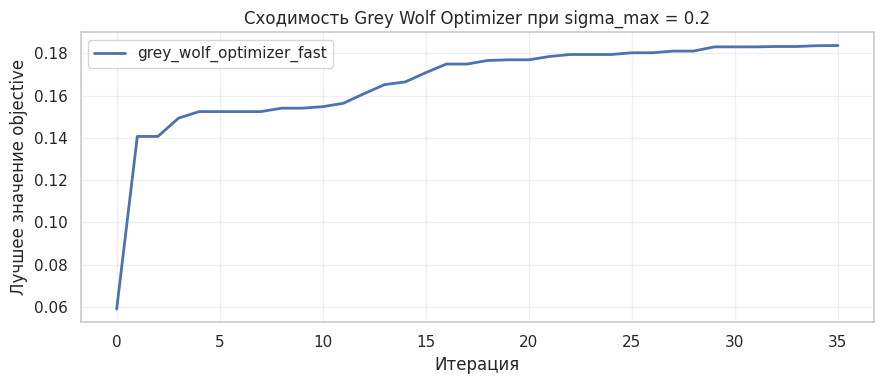

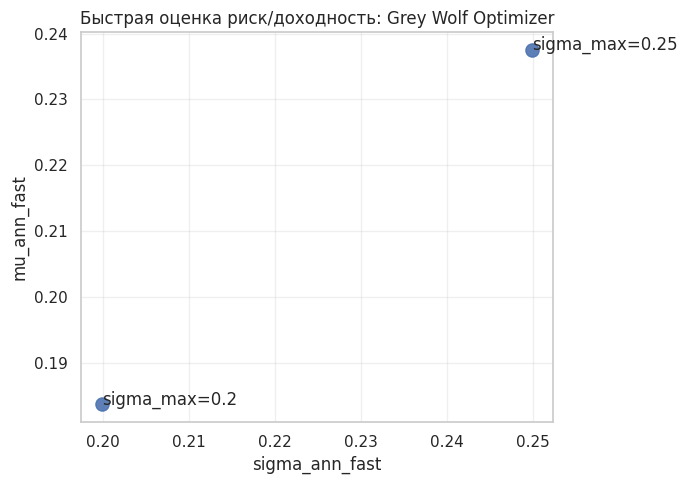

In [ ]:
plt.figure(figsize=(9, 4))
for name, curve in convergence_curves.items():
    plt.plot(range(len(curve)), curve, label=name, linewidth=2)
plt.xlabel("Итерация")
plt.ylabel("Лучшее значение objective")
plt.title(f"Сходимость Grey Wolf Optimizer при sigma_max = {CONVERGENCE_SIGMA}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 5))
plt.scatter(results_df["sigma_ann_fast"], results_df["mu_ann_fast"], s=90, alpha=0.9)
for _, row in results_df.iterrows():
    plt.annotate(f"sigma_max={row['sigma_max']}", (row["sigma_ann_fast"], row["mu_ann_fast"]))
plt.xlabel("sigma_ann_fast")
plt.ylabel("mu_ann_fast")
plt.title("Быстрая оценка риск/доходность: Grey Wolf Optimizer")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Выбор лучшего портфеля: max mu_ann_fast среди feasible_fast
algorithm          grey_wolf_optimizer_fast
sigma_max                              0.25
mu_ann_fast                        0.237499
sigma_ann_fast                     0.249815
n_assets                                 10
budget_used                    988787.58672
cash_left                       11212.41328
feasible_fast                          True
objective_score                    0.237499

Позиции: тикер → лоты → доля → стоимость
  BSPB         lots=   729  weight=0.2500  value=247,058.10
  FESH         lots=  3398  weight=0.2500  value=247,034.60
  PLZL         lots=    56  weight=0.1189  value=117,544.00
  TATNP        lots=   186  weight=0.1034  value=102,207.00
  PHOR         lots=    15  weight=0.1021  value=100,950.00
  SBERP        lots=   126  weight=0.0408  value=40,306.14
  MOEX         lots=   215  weight=0.0364  value=36,021.10
  LKOH         lots=     6  weight=0.0335  value=33,108.00
  MTSS         lots=   14

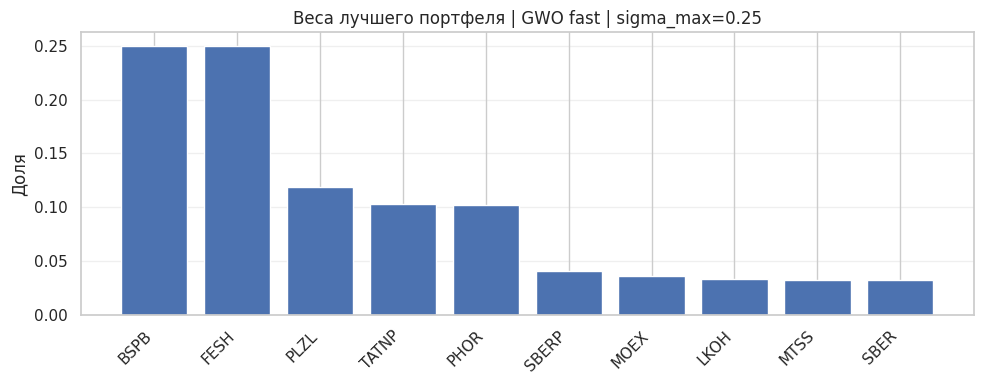


Финальная проверка через исходную функцию portfolio_metrics_rolling:


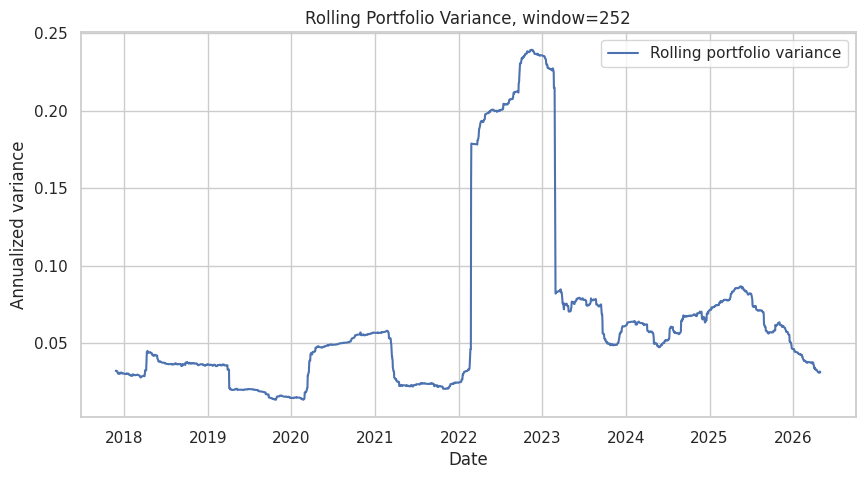

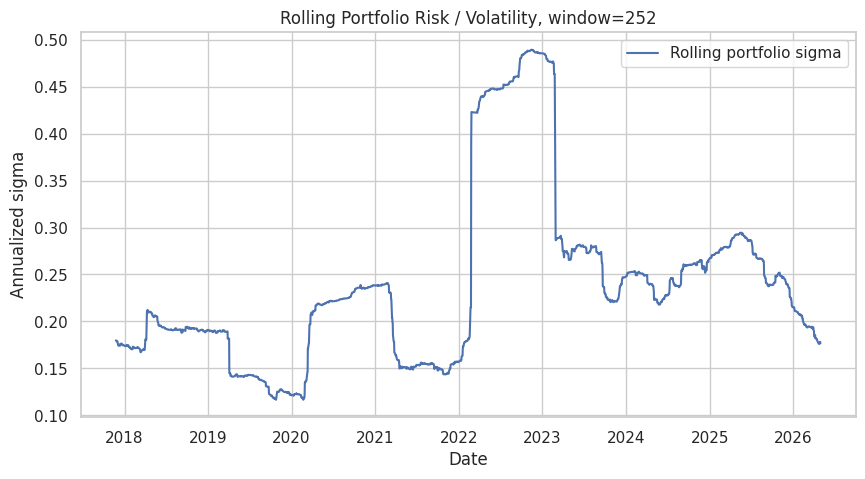

{'weights': PHOR     0.102146
 BSPB     0.249985
 FESH     0.249961
 PLZL     0.118936
 TATNP    0.103418
 SBERP    0.040784
 LKOH     0.033500
 MOEX     0.036448
 SBER     0.032360
 MTSS     0.032464
 dtype: float64,
 'mu_ann': 0.23749878601209787,
 'rolling_var_ann': 2017-11-24    0.032336
 2017-11-27    0.032258
 2017-11-28    0.031975
 2017-11-29    0.031974
 2017-11-30    0.031933
                 ...   
 2026-04-24    0.030998
 2026-04-27    0.031439
 2026-04-28    0.031782
 2026-04-29    0.031782
 2026-04-30    0.031226
 Name: rolling_var_ann, Length: 2135, dtype: float64,
 'rolling_sigma_ann': 2017-11-24    0.179821
 2017-11-27    0.179604
 2017-11-28    0.178815
 2017-11-29    0.178814
 2017-11-30    0.178697
                 ...   
 2026-04-24    0.176063
 2026-04-27    0.177311
 2026-04-28    0.178276
 2026-04-29    0.178274
 2026-04-30    0.176708
 Name: rolling_sigma_ann, Length: 2135, dtype: float64,
 'mean_var_ann': 0.06602888708976443,
 'median_var_ann': 0.0500415809061

In [ ]:
feas_df = results_df[results_df["feasible_fast"]]
if len(feas_df):
    best_idx = feas_df["mu_ann_fast"].idxmax()
    pick_reason = "max mu_ann_fast среди feasible_fast"
else:
    best_idx = results_df["objective_score"].idxmax()
    pick_reason = "нет feasible_fast — max objective с penalty"

best_row = results_df.loc[best_idx]
algo_best = "grey_wolf_optimizer_fast"
smax_best = float(best_row["sigma_max"])
lots_star = ALL_BEST_LOTS[(algo_best, smax_best)].copy()
w_star = lots_to_weights(lots_star)
wd_best = weights_dict_from_vec(w_star)

print("Выбор лучшего портфеля:", pick_reason)
print(best_row.to_string())
print("\nПозиции: тикер → лоты → доля → стоимость")
active_idx = np.where(lots_star > 0)[0]
active_idx = active_idx[np.argsort(-(lots_star[active_idx] * LOT_VALUE[active_idx]))]
for i in active_idx:
    print(f"  {OPT_TICKERS[i]:12s} lots={int(lots_star[i]):6d}  weight={w_star[i]:.4f}  value={lots_star[i] * LOT_VALUE[i]:,.2f}")

if wd_best:
    ticks, vals = zip(*sorted(wd_best.items(), key=lambda kv: -kv[1]))
    plt.figure(figsize=(10, 4))
    plt.bar(range(len(vals)), vals, tick_label=ticks)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Доля")
    plt.title(f"Веса лучшего портфеля | GWO fast | sigma_max={smax_best}")
    plt.grid(True, axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

print("\nФинальная проверка через исходную функцию portfolio_metrics_rolling:")
portfolio_metrics_rolling(
    wd_best,
    prices,
    window=252,
    trading_days=252,
    plot=True,
)
